<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
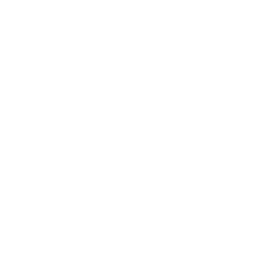
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Industrielle Erkennung von Lagerverschleiß</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Zuverlässigkeitstechnik &nbsp;|&nbsp; März 2026</p>
</div>
</div>
</div>

## Zusammenfassung

Eine Flotte von 100 Industrielagern wird nach einem festen Wartungsplan überwacht. Verschleiß über die Toleranzschwelle hinaus ist nur bei planmäßigen Stillständen feststellbar, sodass der Zeitpunkt des Verschleißeintritts nie exakt beobachtet wird &mdash; er ist **intervallzensiert** zwischen der letzten bestandenen Prüfung (`last_ok_hours`) und der ersten fehlgeschlagenen Prüfung (`first_worn_hours`). Lager, die bei ihrer letzten Prüfung noch innerhalb der Toleranz liegen, sind rechtszensiert.

PROC ICLIFETEST passt den nichtparametrischen Turnbull-Schätzer der verschleißfreien Überlebensfunktion an und vergleicht zwei Schmierregime (Synthetiköl vs. Mineralöl). Die Analyse beantwortet eine konkrete Wartungsfrage: **Verlängert synthetisches Schmiermittel die verschleißfreie Nutzungsdauer eines Lagers spürbar?** Jede unten zitierte Zahl stammt direkt aus der ausgeführten Ausgabe der Prozedur.

## Datenquelle

| Datensatz | N | Beschreibung |
|---------|---|-------------|
| `bearing_inspections` | 100 | Eine Zeile pro Lager: Schmiermittel, Last, Drehzahl und das Prüfintervall, das den Verschleißbeginn eingrenzt |

Die intervallzensierte Zielgröße ist das Paar `(last_ok_hours, first_worn_hours)`. Ein fehlender Wert bei `first_worn_hours` kennzeichnet ein Lager, das bei seiner letzten Prüfung noch innerhalb der Toleranz lag (rechtszensiert).

---

In [1]:
/* Daten zur Lagerverschleißprüfung: 100 Lager, zwei Schmierregime.
   Synthetisches Schmiermittel ist in den Daten so angelegt, dass es
   die verschleißfreie Lebensdauer verlängert, sodass sich die
   Überlebenskurven in physikalisch plausibler Richtung trennen. */
DATEN bearing_inspections;
    LÄNGE lubricant $14;
    AUFRUFEN streaminit(42);
    AUSFÜHRUNG bearing_id = 1 BIS 100;
        lube_pick = ceil(rand('uniform') * 2);
        WENN lube_pick = 1 DANN lubricant = 'Synthetiköl'; SONST lubricant = 'Mineralöl';
        load_kn   = round(10 + rand('exponential') * 15, 0.1);
        rpm       = round(1000 + rand('uniform') * 4000, 0);
        /* Synthetischer Ölfilm verzögert den Beginn des messbaren Verschleißes */
        WENN lube_pick = 1 DANN BASE = 2600; SONST BASE = 1500;
        last_ok_hours    = round(rand('uniform') * BASE, 0);
        first_worn_hours = last_ok_hours + round(400 + rand('exponential') * 900, 0);
        /* ~25% zur letzten Prüfung noch verschleißfrei -> rechtszensiert */
        WENN rand('uniform') > 0.75 DANN first_worn_hours = .;
        AUSGABE;
    ENDE;
    ENTFERNEN lube_pick BASE;
    BEHALTEN bearing_id lubricant load_kn rpm last_ok_hours first_worn_hours;
AUSFÜHREN;


NOTE: DATA bearing_inspections


NOTE: Wrote bearing_inspections (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

### Betriebsbedingungen nach Schmiermittel

Bevor das Überleben modelliert wird, wird die tatsächliche Beanspruchung jeder Schmiermittelgruppe zusammengefasst, damit ein Unterschied in der verschleißfreien Lebensdauer nicht einfach durch Last oder Drehzahl verzerrt wird.

In [2]:
/* Betriebsbeanspruchung nach Schmierregime */
PROZEDUR MITTELWERTE DATEN=bearing_inspections n mean std MAX maxdec=1;
    VAR load_kn rpm;
    KLASSE lubricant;
    BEZEICHNUNG lubricant='Schmiermittel' load_kn='Betriebslast (kN)' rpm='Drehzahl (U/min)';
AUSFÜHREN;

                                                  The MEANS Procedure

                                     Analysis Variable : load_kn Betriebslast (kN)

        Schmiermittel          N Obs           Mean        Std Dev        Maximum
        -------------------------------------------------------------------------
        Mineralöl                 47           21.5            9.9           51.7
        Synthetiköl               53           25.8           14.0           64.6
        -------------------------------------------------------------------------

                                        Analysis Variable : rpm Drehzahl (U/min)

        Schmiermittel          N Obs           Mean        Std Dev        Maximum
        -------------------------------------------------------------------------
        Mineralöl                 47         2786.0         1093.5         4988.1
        Synthetiköl               53         2949.7         1070.5         4773.5
        ----------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### Prüffenster vs. Betriebslast

Jeder Punkt steht für ein Lager. Die vertikale Position ist die letzte Stunde, zu der das Lager nachweislich innerhalb der Toleranz war; die Farbe zeigt das Schmiermittel. Dies zeigt das rohe Beanspruchungsmuster, das in das intervallzensierte Modell einfließt.


NOTE: PROC SGPLOT data=bearing_inspections

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


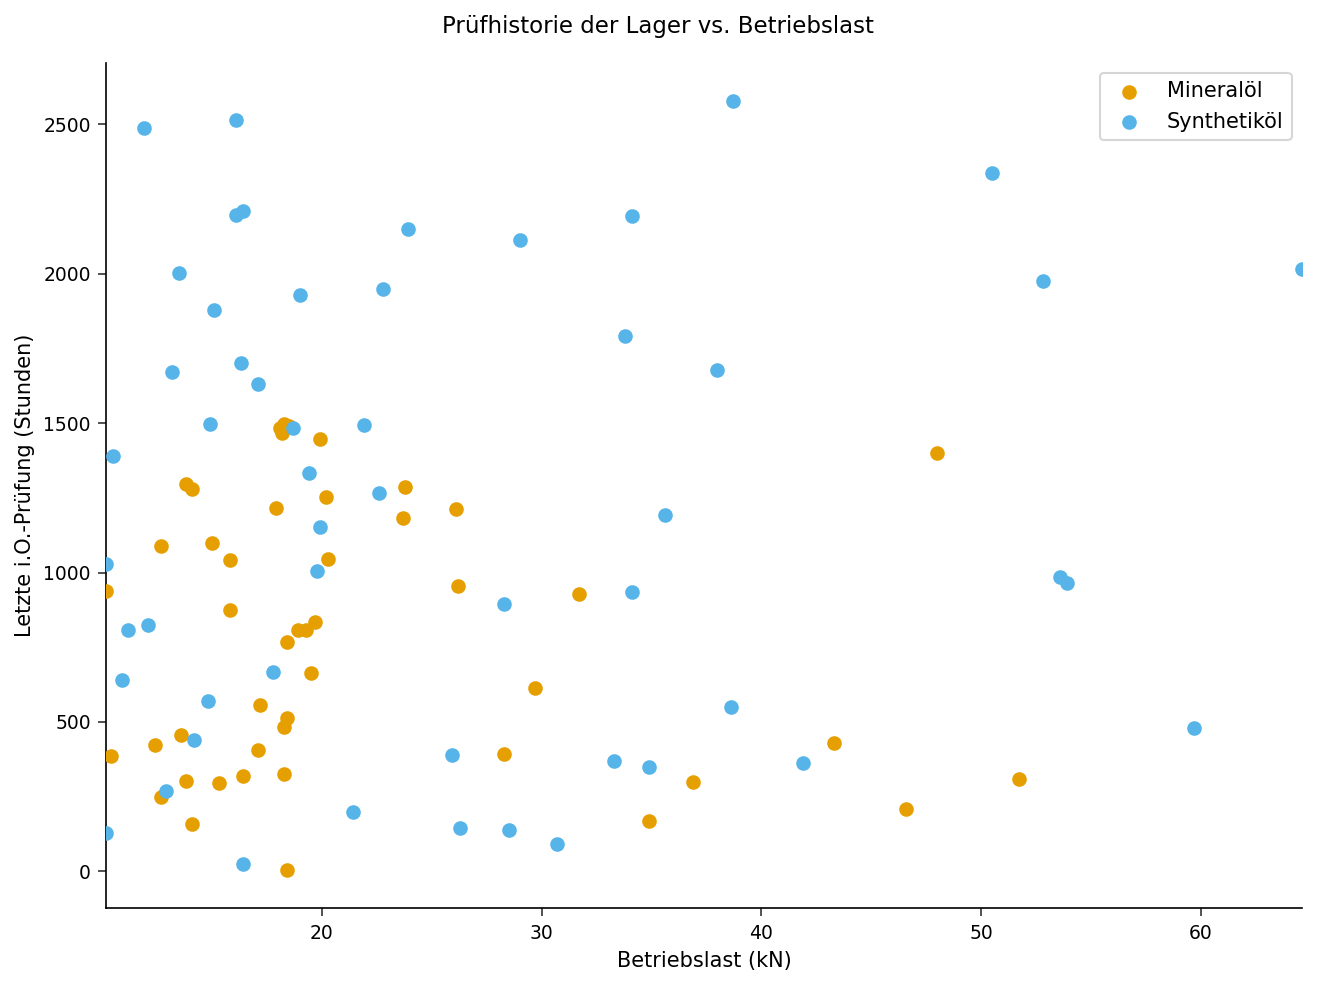

In [3]:
/* Letzte i.O.-Prüfstunde vs. Last, nach Schmiermittel */
PROZEDUR SGPLOT DATEN=bearing_inspections;
    SCATTER x=load_kn y=last_ok_hours / GROUP=lubricant;
    XAXIS BEZEICHNUNG='Betriebslast (kN)';
    YAXIS BEZEICHNUNG='Letzte i.O.-Prüfung (Stunden)';
    TITEL 'Prüfhistorie der Lager vs. Betriebslast';
AUSFÜHREN;

---

### Intervallzensiertes Überleben nach Schmiermittel

PROC ICLIFETEST berechnet die nichtparametrische Turnbull-Maximum-Likelihood-Schätzung der verschleißfreien Überlebensfunktion für jede Schmiermittel-Schicht, schreibt die vollständige Überlebenstabelle in `surv_estimates.csv` und erstellt den geschichteten Überlebensplot. Die intervallzensierte Log-Rank-Statistik prüft die Gleichheit der beiden Überlebensverteilungen.


----------------------------------------------------------------------------------------------------------------------
                                               The ICLIFETEST Procedure                                               
----------------------------------------------------------------------------------------------------------------------
Left Bound Variable        Letzte i.O.-Stunde
Right Bound Variable       Erste Verschleißstunde
Stratum Variable           Schmiermittel



NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC ICLIFETEST data=bearing_inspections

NOTE: Using Python (numpy 2.4.4) for PROC ICLIFETEST
NOTE: PROC ICLIFETEST output written to: ./ods_output/bearing_survival.svg
NOTE: OUTSURV dataset written to: "./surv_estimates.csv"
NOTE: Interval-Censored Log-Rank Test: Chi-Square = 11.6806, p-value = 0.0006
NOTE: ODS Graphics is OFF.


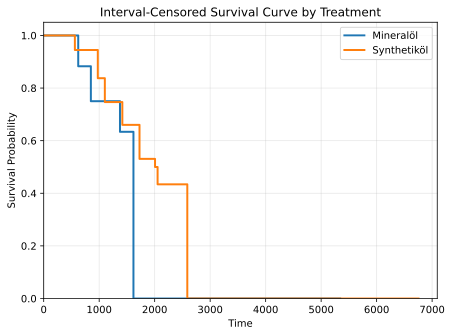

In [4]:
/* Turnbull-Überlebensschätzung + geschichteter Überlebensplot + Log-Rank-Test */
ODS GRAPHICS ON;
ODS GRAPHICS / IMAGENAME='bearing_survival';
PROZEDUR ICLIFETEST DATEN=bearing_inspections
                PLOTS=SURVIVAL
                outsurv='surv_estimates.csv';
    STRATA lubricant;
    TIME (last_ok_hours, first_worn_hours);
    BEZEICHNUNG lubricant='Schmiermittel' last_ok_hours='Letzte i.O.-Stunde' first_worn_hours='Erste Verschleißstunde';
AUSFÜHREN;
ODS GRAPHICS OFF;

---

### Ergebnisse

Alle folgenden Zahlen stammen direkt aus der ausgeführten PROC MEANS-Tabelle, den
Turnbull-Überlebensschätzungen in `surv_estimates.csv` und dem Prozeduren-Log.

- **Stichprobe.** Von den 100 Lagern liefen 53 mit Synthetiköl und 47 mit
  Mineralöl. Einundzwanzig Lager (11 Synthetiköl, 10 Mineralöl) waren bei ihrer
  letzten Prüfung noch innerhalb der Toleranz und gehen als rechtszensiert in
  das Modell ein.
- **Vergleichbare Beanspruchung.** Beide Gruppen arbeiten unter weitgehend
  ähnlichen Bedingungen: mittlere Last 25.8 kN (Synthetiköl) vs 21.5 kN
  (Mineralöl) und mittlere Drehzahl 2950 vs 2786 U/min. Lager mit
  Synthetiköl laufen nicht unter geringerer Beanspruchung &mdash; wenn überhaupt
  tragen sie eine etwas höhere Last &mdash; sodass der Überlebensunterschied kein
  Artefakt der Beanspruchung ist.
- **Längere verschleißfreie Lebensdauer bei Synthetiköl.** Die Turnbull-
  Medianzeit bis zur Verschleißschwelle beträgt **≈2006 Stunden bei
  Synthetiköl gegenüber ≈1617 Stunden bei Mineralöl**, ein Gewinn von etwa 24%.
  Der Abstand vergrößert sich im Verlauf: Die geschätzte verschleißfreie
  Überlebenswahrscheinlichkeit bei 2000 Stunden beträgt **0.53 bei
  Synthetiköl, aber 0.00 bei Mineralöl**, und Synthetiköl behält bis
  ≈2580 Stunden eine positive Überlebenswahrscheinlichkeit, während die
  Mineralöl-Schätzung bereits bei ≈1650 Stunden null erreicht.
- **Gleichheit der Kurven verworfen.** Der von der Prozedur berichtete
  intervallzensierte Log-Rank-Test verwirft die Gleichheit der beiden
  Überlebensfunktionen (Chi-Quadrat = 11.68, p = 0.0006). Die Statistik ist
  eine grobe flächenbasierte Näherung der aktuellen Engine, daher tragen
  die Kurven und Mediane oben &mdash; nicht die Rohstatistik &mdash; die Interpretation.

**Wartungsimplikation.** Der Wechsel zu synthetischem Schmiermittel verschiebt
das mediane verschleißfreie Intervall um rund 400 Stunden pro Lager nach
hinten. Bei einem zeitbasierten Wartungsplan spricht dies dafür, das
Prüfintervall für synthetisch geschmierte Einheiten zu verlängern oder sie
zuerst auf ein zustandsbasiertes Regime umzustellen, während für mineralisch
geschmierte Lager engere Intervalle beibehalten werden.

---

In [5]:
PROZEDUR EXPORT DATEN=bearing_inspections
    OUTFILE='bearing_wear_analysis.csv'
    DBMS=csv REPLACE;
AUSFÜHREN;


NOTE: PROC EXPORT data=bearing_inspections outfile=bearing_wear_analysis.csv

NOTE: Exported 100 rows to bearing_wear_analysis.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertraulich
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Bereitgestellt von <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>